#LabWeek9: Prevent Overfitting - Part I

## Importing Dataset: IMDB

In [42]:
from keras.datasets import imdb
import numpy as np

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] += 1.  # set specific indices of results[i] to 1s
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

**Note:** We first encountered this dataset in `LabWeek5`. You can refer to that notebook for clarification on the text-to-numbers decoding process. Through vectorizing process we turn text data into vectors.

**Perform some sanity checks on the dataset:** For example, find the `shape` of the dataset and print samples to make sense of the data.

In [44]:
#TODO: your code here
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

print("\nFirst 10 values of the first training sample:")
print(x_train[0][:10])

print("\nFirst 5 labels:")
print(y_train[:5])

print("\nUnique labels:")
print(np.unique(y_train))

x_train shape: (25000, 10000)
y_train shape: (25000,)
x_test shape: (25000, 10000)
y_test shape: (25000,)

First 10 values of the first training sample:
[ 0.  1.  6.  0. 15.  9.  3.  2.  3.  1.]

First 5 labels:
[1. 0. 0. 1. 0.]

Unique labels:
[0. 1.]


## Fighting overfitting -  Reducing the network's size


The general workflow to find an appropriate model size is to start with relatively few layers and
parameters, and start increasing the size of the layers or adding new layers until you see diminishing returns with regard to the
validation loss.



**Note:** we use `test set` as our `validation set`.

**Complete the following code for `original model` architecture**

In [24]:
from keras import models
from keras import layers

original_model = models.Sequential()
original_model.add(layers.InputLayer(shape=(10000,)))
original_model.add(layers.Dense(16, activation='relu'))
#TODO: add one hidden layer with 16 units with proper activation function
original_model.add(layers.Dense(16, activation='relu'))

#TODO: add the output layer. Remember our task is binary classificaion, whether a review is 0:negative or 1:positive.
original_model.add(layers.Dense(1, activation='sigmoid'))

original_model.compile(optimizer='rmsprop',
                       loss='binary_crossentropy',
                       metrics=['acc'])

In [25]:
original_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

**Define another model with fewer parameters. 4 units in each hidden layer.**

In [26]:
smaller_model = models.Sequential()
#TODO: add hidden/ouput layers and compile the smaller model
smaller_model.add(layers.InputLayer(shape=(10000,)))
smaller_model.add(layers.Dense(4, activation='relu'))
smaller_model.add(layers.Dense(4, activation='relu'))
smaller_model.add(layers.Dense(1, activation='sigmoid'))

smaller_model.compile(optimizer='rmsprop',
                      loss='binary_crossentropy',
                      metrics=['acc'])


**Train (1) original_model and (2) smaller_model seperately for `epochs=20` and `batch_size=512`. Also pass `x_test` and `y_test` as `validation_data`.**

In [27]:
#TODO: your code here for training original_model
original_hist = original_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test)
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - acc: 0.7642 - loss: 0.5408 - val_acc: 0.8672 - val_loss: 0.4180
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - acc: 0.8869 - loss: 0.3510 - val_acc: 0.8786 - val_loss: 0.3439
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - acc: 0.9084 - loss: 0.2743 - val_acc: 0.8846 - val_loss: 0.3103
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - acc: 0.9201 - loss: 0.2331 - val_acc: 0.8897 - val_loss: 0.2880
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.9289 - loss: 0.2072 - val_acc: 0.8857 - val_loss: 0.2967
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.9363 - loss: 0.1849 - val_acc: 0.8834 - val_loss: 0.3046
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - acc: 0.9446 - loss: 0.1661 - val_acc: 0.8820 - val_loss: 0.3046
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - acc: 0.9463 - loss: 0.1561 - val_acc: 0.8823 - val_loss: 0.3134
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - acc: 0.951

In [28]:
#TODO: your code here for training original_model
smaller_hist = smaller_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test)
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - acc: 0.7178 - loss: 0.6030 - val_acc: 0.8442 - val_loss: 0.4900
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.8768 - loss: 0.4056 - val_acc: 0.8770 - val_loss: 0.3739
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.9042 - loss: 0.3080 - val_acc: 0.8844 - val_loss: 0.3229
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - acc: 0.9180 - loss: 0.2544 - val_acc: 0.8893 - val_loss: 0.2976
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - acc: 0.9258 - loss: 0.2221 - val_acc: 0.8724 - val_loss: 0.3273
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - acc: 0.9348 - loss: 0.1977 - val_acc: 0.8891 - val_loss: 0.2895
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - acc: 0.9386 - loss: 0.1803 - val_acc: 0.8832 - val_loss: 0.3029
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - acc: 0.9448 - loss: 0.1645 - val_acc: 0.8870 - val_loss: 0.2929
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - acc: 0.9493

**`orginal_hist` and `smaller_hist` are `objects` returned after training the models.**
- We can get access to the `history` attribute of `origial_hist` object through dot operator.
- TODO: The history attribute is a data structure of type `dictionary` containing data about everything that happened during training. Show the `keys` of this `dictionary`.

In [29]:
print(original_hist.history)
#TODO: print out the keys of the output dictionary
#your code here
print(original_hist.history.keys())

{'acc': [0.764240026473999, 0.8869199752807617, 0.9083999991416931, 0.9200800061225891, 0.9289199709892273, 0.9363200068473816, 0.9445599913597107, 0.9463199973106384, 0.9512799978256226, 0.955079972743988, 0.961679995059967, 0.9628400206565857, 0.9688799977302551, 0.9702799916267395, 0.9753199815750122, 0.9779599905014038, 0.9787600040435791, 0.981719970703125, 0.9823200106620789, 0.9871600270271301], 'loss': [0.5407994985580444, 0.3510424494743347, 0.2742599546909332, 0.23308293521404266, 0.20715387165546417, 0.1849026381969452, 0.1661187708377838, 0.15611563622951508, 0.14327417314052582, 0.13182593882083893, 0.11984475702047348, 0.11147480458021164, 0.10031233727931976, 0.09674081206321716, 0.08272722363471985, 0.07646764069795609, 0.07201269268989563, 0.06450899690389633, 0.060754310339689255, 0.05087800323963165], 'val_acc': [0.8672000169754028, 0.878600001335144, 0.8845999836921692, 0.8897200226783752, 0.8856800198554993, 0.8833600282669067, 0.8820400238037109, 0.882279992103576

**Plot `val_loss` vs. epochs for both models in one plot**

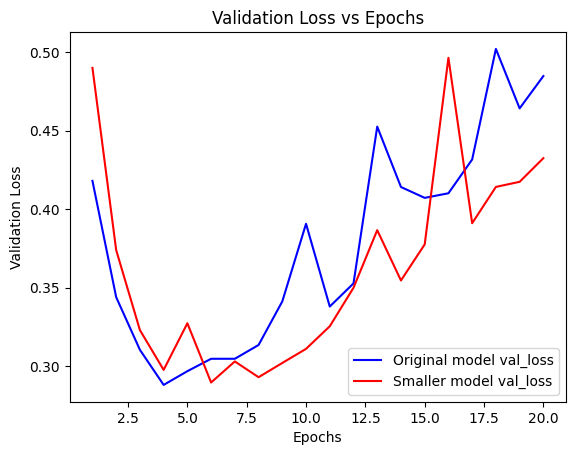

In [39]:
from matplotlib import pyplot as plt
#TODO: your code here
original_loss = original_hist.history['val_loss']
smaller_loss = smaller_hist.history['val_loss']

epochs = range(1, len(original_loss) + 1)

plt.plot(epochs, original_loss, 'b-', label='Original model val_loss')
plt.plot(epochs, smaller_loss, 'r-', label='Smaller model val_loss')
plt.title('Validation Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

**Plot training `loss` vs. epochs for both models in one plot**

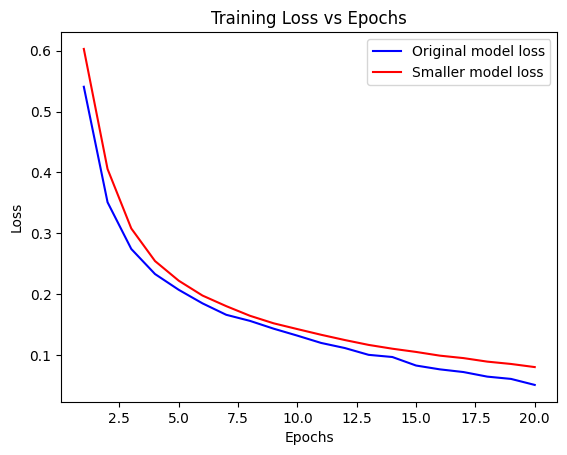

In [40]:
#TODO: your code here
original_train_loss = original_hist.history['loss']
smaller_train_loss = smaller_hist.history['loss']

plt.plot(epochs, original_train_loss, 'b-', label='Original model loss')
plt.plot(epochs, smaller_train_loss, 'r-', label='Smaller model loss')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Questions:** Which model overfits earlier? How can you see the size of the model on overfitting?

**Answer:** The original model overfits earlier than the smaller model.
This can be seen because its training loss keeps decreasing while its validation loss starts increasing sooner.
The size of the model affects overfitting because larger models have more parameters and higher capacity,
so they can memorize the training data faster and overfit more easily.

**Now define a very large model (e.g., with 512 units in hidden layer) and compare the `loss` and `val_loss` of this big model and the `original model` and `smaller_model`.**

In [32]:
#your code here
big_model = models.Sequential()
big_model.add(layers.InputLayer(shape=(10000,)))
big_model.add(layers.Dense(512, activation='relu'))
big_model.add(layers.Dense(512, activation='relu'))
big_model.add(layers.Dense(1, activation='sigmoid'))

big_model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['acc'])

big_hist = big_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test)
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 444ms/step - acc: 0.7247 - loss: 0.6026 - val_acc: 0.8330 - val_loss: 0.3967
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 366ms/step - acc: 0.8674 - loss: 0.3366 - val_acc: 0.8412 - val_loss: 0.3697
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 373ms/step - acc: 0.8957 - loss: 0.2611 - val_acc: 0.8843 - val_loss: 0.2829
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 370ms/step - acc: 0.9152 - loss: 0.2087 - val_acc: 0.7917 - val_loss: 0.4710
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 406ms/step - acc: 0.9338 - loss: 0.1731 - val_acc: 0.8781 - val_loss: 0.2851
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 372ms/step - acc: 0.9502 - loss: 0.1367 - val_acc: 0.8877 - val_loss: 0.2932
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 482ms/step - acc: 0.9654 - loss: 0.1021 - val_acc: 0.8832 - val_loss: 0.3358
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 368ms/step - acc: 0.9750 - loss: 0.0742 - val_acc: 0.8830 - val_loss: 0.4048
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 410ms/

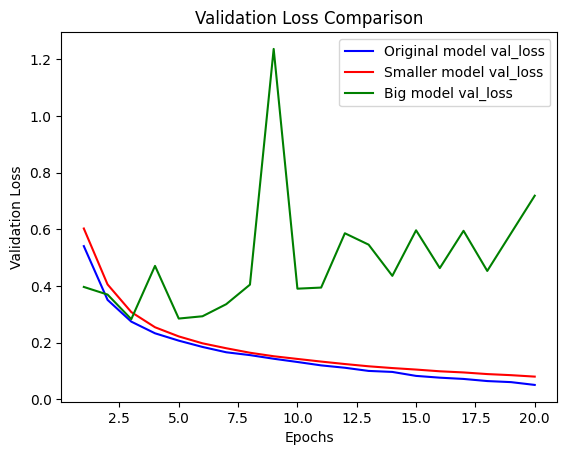

In [33]:
big_val_loss = big_hist.history['val_loss']

plt.plot(epochs, original_loss, 'b-', label='Original model val_loss')
plt.plot(epochs, smaller_loss, 'r-', label='Smaller model val_loss')
plt.plot(epochs, big_val_loss, 'g-', label='Big model val_loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

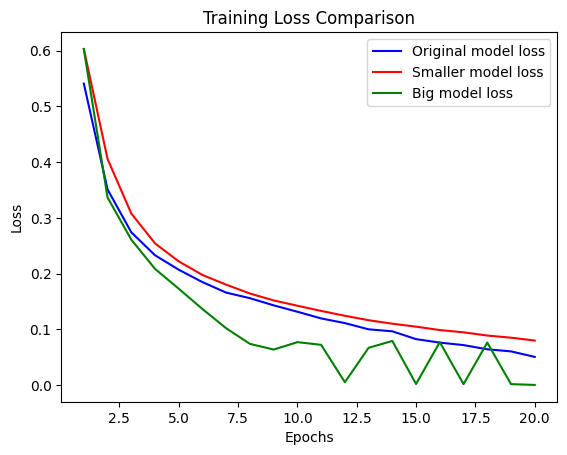

In [34]:
big_loss = big_hist.history['loss']

plt.plot(epochs, original_loss, 'b-', label='Original model loss')
plt.plot(epochs, smaller_loss, 'r-', label='Smaller model loss')
plt.plot(epochs, big_loss, 'g-', label='Big model loss')
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Discuss the results**

**Answer:** The big model usually reaches very low training loss much faster than the original and smaller models,
which shows it has much higher capacity. However, its validation loss tends to increase earlier and more sharply,
showing stronger overfitting. The smaller model trains more slowly and may not fit the training data as perfectly,
but it generally overfits later and can generalize better for longer.

## Fighting overfitting - Adding weight regularization


A common way to mitigate overfitting is to put constraints on the complexity
of a network by forcing its weights to only take small values. This is called
"weight regularization", and it is done by adding to the loss function of the network a _cost_ associated with having large weights. This
cost comes in two flavors:

* L1 regularization, where the cost added is proportional to the _absolute value of the weights coefficients_ (i.e. to what is called the
"L1 norm" of the weights).
* L2 regularization, where the cost added is proportional to the _square of the value of the weights coefficients_ (i.e. to what is called
the "L2 norm" of the weights). L2 regularization is also called _weight decay_ in the context of neural networks. Don't let the different
name confuse you: weight decay is mathematically the exact same as L2 regularization.

In Keras, weight regularization is added by passing _weight regularizer instances_ to layers as keyword arguments.


**Complere the model below**

In [35]:
from keras import regularizers

l2_model = models.Sequential()
l2_model.add(layers.InputLayer(shape=(10000,)))
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),
                          activation='relu'))

#TODO: Add a dense layer with 16 unuts with L2 regularization
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),
                          activation='relu'))

l2_model.add(layers.Dense(1, activation='sigmoid'))

In [36]:
l2_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['acc'])

`l2(0.001)` means that every coefficient in the weight matrix of the layer will add `0.001 * weight_coefficient_value` to the total loss of
the network. Note that because this penalty is _only added at training time_, the loss for this network will be much higher at training
than at test time.



**Train the model with regularization and compare the validation loss between this model and the `original_model` and `smaller model`.**

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - acc: 0.7870 - loss: 0.5566 - val_acc: 0.8667 - val_loss: 0.4447
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - acc: 0.8891 - loss: 0.3772 - val_acc: 0.8769 - val_loss: 0.3774
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.9042 - loss: 0.3180 - val_acc: 0.8834 - val_loss: 0.3518
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - acc: 0.9145 - loss: 0.2889 - val_acc: 0.8871 - val_loss: 0.3390
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - acc: 0.9207 - loss: 0.2718 - val_acc: 0.8681 - val_loss: 0.3853
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - acc: 0.9251 - loss: 0.2599 - val_acc: 0.8868 - val_loss: 0.3371
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.9311 - loss: 0.2462 - val_acc: 0.8802 - val_loss: 0.3572
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.9322 - loss: 0.2436 - val_acc: 0.8861 - val_loss: 0.3429
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.9362

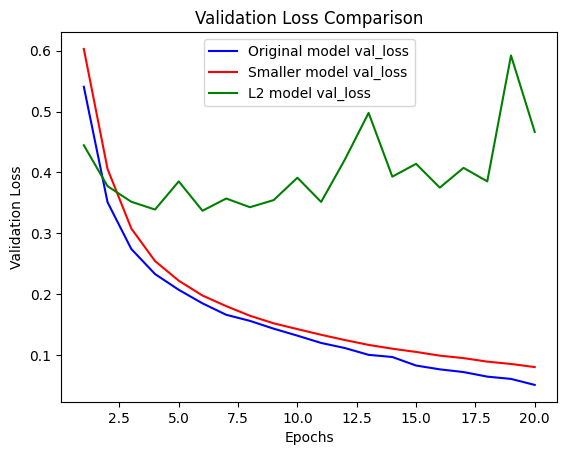

In [37]:
#TODO: your code here
l2_hist = l2_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_test, y_test)
)

l2_val_loss = l2_hist.history['val_loss']

plt.plot(epochs, original_loss, 'b-', label='Original model val_loss')
plt.plot(epochs, smaller_loss, 'r-', label='Smaller model val_loss')
plt.plot(epochs, l2_val_loss, 'g-', label='L2 model val_loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

**Note:** As alternatives to L2 regularization, you could use one of the following Keras weight regularizers:

In [38]:
from keras import regularizers

# L1 regularization
regularizers.l1(0.001)

# L1 and L2 regularization at the same time
regularizers.l1_l2(l1=0.001, l2=0.001)

## Recap

To recap: here the most common ways to prevent overfitting in neural networks:

* Getting more training data.
* Reducing the capacity of the network.
* Adding weight regularization.
* Adding dropout. (next session)

**Observation 1:** The bigger network gets its training loss near zero very quickly. The more capacity the network has, the quicker it will be
able to model the training data (resulting in a low training loss), but the more susceptible it is to overfitting (resulting in a large
difference between the training and validation loss).

**Observation 2:** The model with L2 regularization has become much more resistant to overfitting than the reference model,
even though both models have the same number of parameters.